# SPX (.SPX rv5_ss) vs SPY (QMLE-Trade) — correlation check

This notebook loads:
- **OMI Realised Library.csv** (Column A: date, Column B: symbol filter `.SPX`, Column C: `rv5_ss`)
- **SPY.csv** (Column A: symbol=`SPY`, Column C: type filter `QMLE-Trade`, Column D: date, Column E: realised volatility)

It parses, aligns by date, and reports the Pearson correlation and two-sided p-value.
> **Note on units**: In many OMI dumps, `rv5_ss` is a *realised variance* (daily) measure, while your SPY file’s `Volatility` column looks like an **annualised realised volatility** (~0.10–0.30 typical). If units differ, the notebook can optionally convert OMI to annualised volatility via `sqrt(rv) * sqrt(252)`. Both results are reported for transparency.


In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Parameters (edit paths if needed) ----
omi_path = 'OMI Realised Library.csv'  # Column A: date; Column B: symbol; Column C: rv5_ss
spy_path = 'SPY.csv'                  # Col A: symbol; Col C: type; Col D: date; Col E: volatility

# If True, also compute correlation after converting OMI rv to annualised vol via sqrt * sqrt(252).
assess_unit_mismatch = True


In [3]:
def _pearsonr_with_pvalue(x, y):
    import numpy as _np, math as _math
    x = _np.asarray(x, dtype=float)
    y = _np.asarray(y, dtype=float)
    mask = _np.isfinite(x) & _np.isfinite(y)
    x, y = x[mask], y[mask]
    n = len(x)
    if n < 3:
        return _np.nan, _np.nan, n, max(n-2, 0), 'insufficient data'
    r = _np.corrcoef(x, y)[0, 1]
    r = float(_np.clip(r, -1.0, 1.0))
    df = n - 2
    if abs(r) == 1.0:
        t_stat = _np.inf
    else:
        t_stat = r * _math.sqrt(df / max(1e-15, (1.0 - r*r)))
    try:
        from scipy.stats import t as _t
        p = 2.0 * _t.sf(abs(t_stat), df)
        method = 'Student t (SciPy)'
    except Exception:
        p = _math.erfc(abs(t_stat) / _math.sqrt(2.0))
        method = 'Normal approximation'
    return r, p, n, df, method

def _fisher_ci(r, n, alpha=0.05):
    import numpy as _np, math as _math
    if n < 4 or not _np.isfinite(r):
        return (_np.nan, _np.nan)
    r = float(_np.clip(r, -0.999999, 0.999999))
    z = _np.arctanh(r)
    se = 1.0 / _math.sqrt(max(1, n - 3))
    zcrit = 1.959963984540054  # 95% CI
    lo = _np.tanh(z - zcrit * se)
    hi = _np.tanh(z + zcrit * se)
    return float(lo), float(hi)


In [7]:
# ---- Load & parse OMI (.SPX) ----
omi_raw = pd.read_csv(omi_path)
# Use explicit column names when available; fallback to first three columns
if set(['Unnamed: 0','Symbol','rv5_ss']).issubset(omi_raw.columns):
    omi = omi_raw.loc[:, ['Unnamed: 0','Symbol','rv5_ss']].copy()
    omi.columns = ['date','symbol','rv5_ss']
else:
    omi = omi_raw.iloc[:, :3].copy()
    omi.columns = ['date','symbol','rv5_ss']

omi['symbol'] = omi['symbol'].astype(str).str.strip()
omi = omi[omi['symbol'] == '.SPX'].copy()

# Make date naive date-only (drop timezone and time)
omi['date'] = pd.to_datetime(omi['date'], utc=True, errors='coerce').dt.tz_convert(None).dt.date
omi['rv5_ss'] = pd.to_numeric(omi['rv5_ss'], errors='coerce')

omi_daily = (
    omi.dropna(subset=['date']).groupby('date', as_index=True)['rv5_ss']
       .mean().rename('omi_rv').sort_index()
)

# ---- Load & parse SPY (QMLE-Trade) ----
spy_raw = pd.read_csv(spy_path)
if set(['Symbol','Type','Date','Volatility']).issubset(spy_raw.columns):
    spy = spy_raw.loc[:, ['Symbol','Type','Date','Volatility']].copy()
else:
    # Position-based fallback: A, C, D, E
    spy = spy_raw.iloc[:, [0,2,3,4]].copy()
    spy.columns = ['Symbol','Type','Date','Volatility']

spy = spy[
    (spy['Symbol'].astype(str).str.strip().str.upper() == 'SPY') &
    (spy['Type'].astype(str).str.strip().str.upper() == 'QMLE-TRADE')
].copy()

spy['date'] = pd.to_datetime(spy['Date'], errors='coerce').dt.date
spy['Volatility'] = pd.to_numeric(spy['Volatility'], errors='coerce')

spy_daily = (
    spy.dropna(subset=['date']).groupby('date', as_index=True)['Volatility']
       .mean().rename('spy_rv').sort_index()
)

merged = pd.concat([omi_daily, spy_daily], axis=1, join='inner').dropna()

print(f'Overlapping days: {len(merged)}')
display(merged.head(10))


Overlapping days: 4866


,omi_rv,spy_rv
date,,
2000-01-03,0.000141,0.220507
2000-01-04,0.000224,0.227556
2000-01-05,0.000314,0.292179
2000-01-06,0.000131,0.211642
2000-01-07,0.000094,0.179504
2000-01-10,0.000120,0.137960
2000-01-11,0.000068,0.144696
2000-01-12,0.000123,0.194423
2000-01-13,0.000101,0.138575


In [8]:
# ---- Correlation(s) ----
def _summarize_corr(x, y):
    r, p, n, df, method = _pearsonr_with_pvalue(x, y)
    lo, hi = _fisher_ci(r, n)
    return {'n': n, 'pearson_r': r, 'p_value_two_sided': p, 'r_95pct_CI_low': lo, 'r_95pct_CI_high': hi, 'method': method}

as_is = _summarize_corr(merged['omi_rv'].values, merged['spy_rv'].values)

if assess_unit_mismatch:
    # Convert OMI realised variance to annualised volatility (if needed): sqrt(.) * sqrt(252)
    omi_as_vol_ann = np.sqrt(np.maximum(merged['omi_rv'].values, 0.0)) * math.sqrt(252.0)
    transformed = _summarize_corr(omi_as_vol_ann, merged['spy_rv'].values)
else:
    transformed = None

print('As-is correlation:', as_is)
if transformed:
    print('After sqrt & annualise correlation (OMI -> vol):', transformed)

# Simple OLS fit for context: y = a + b x
if len(merged) >= 2:
    b, a = np.polyfit(merged['omi_rv'].values, merged['spy_rv'].values, 1)
    print({'OLS_intercept_a': float(a), 'OLS_slope_b': float(b)})


As-is correlation: {'n': 4866, 'pearson_r': 0.7692234581392434, 'p_value_two_sided': 0.0, 'r_95pct_CI_low': 0.7574975707027275, 'r_95pct_CI_high': 0.7804531840958381, 'method': 'Student t (SciPy)'}
After sqrt & annualise correlation (OMI -> vol): {'n': 4866, 'pearson_r': 0.9030188287474696, 'p_value_two_sided': 0.0, 'r_95pct_CI_low': 0.8976980663441989, 'r_95pct_CI_high': 0.9080762612054232, 'method': 'Student t (SciPy)'}
{'OLS_intercept_a': 0.09945908839436289, 'OLS_slope_b': 251.68451950671826}


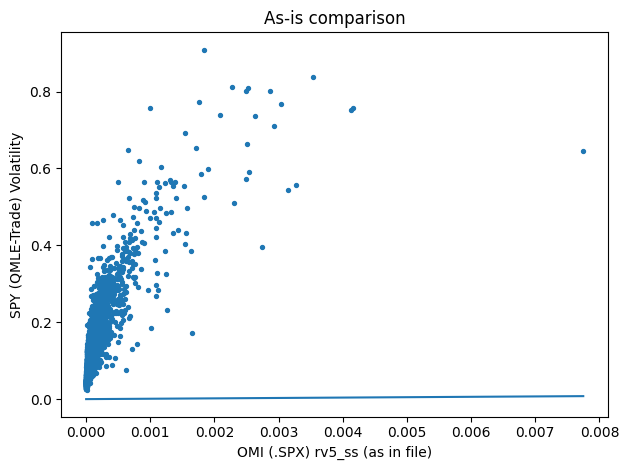

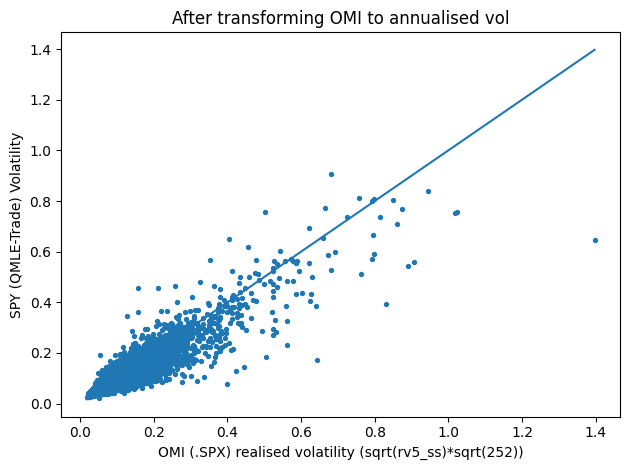

In [9]:
# ---- Quick scatter (as-is) ----
if len(merged) >= 2:
    plt.figure()
    plt.scatter(merged['omi_rv'], merged['spy_rv'], s=8)
    xmin, xmax = float(np.nanmin(merged['omi_rv'])), float(np.nanmax(merged['omi_rv']))
    xref = np.linspace(xmin, xmax, 100)
    plt.plot(xref, xref)  # y=x reference
    plt.xlabel('OMI (.SPX) rv5_ss (as in file)')
    plt.ylabel('SPY (QMLE-Trade) Volatility')
    plt.title('As-is comparison')
    plt.tight_layout()
    plt.show()

# ---- Quick scatter (after transform) ----
if assess_unit_mismatch and len(merged) >= 2:
    plt.figure()
    x_t = np.sqrt(np.maximum(merged['omi_rv'].values, 0.0)) * math.sqrt(252.0)
    plt.scatter(x_t, merged['spy_rv'].values, s=8)
    xmin, xmax = float(np.nanmin(x_t)), float(np.nanmax(x_t))
    xref = np.linspace(xmin, xmax, 100)
    plt.plot(xref, xref)  # y=x
    plt.xlabel('OMI (.SPX) realised volatility (sqrt(rv5_ss)*sqrt(252))')
    plt.ylabel('SPY (QMLE-Trade) Volatility')
    plt.title('After transforming OMI to annualised vol')
    plt.tight_layout()
    plt.show()
